In [23]:
# ==========================================
# CELL 1: HPC SETUP & DUAL-PINN ARCHITECTURE
# ==========================================

import torch
import torch.nn as nn

# 1. HPC Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

# 2. Network Architectures (The Dual-NN Setup)
# [Rasht-Behesht 2022 Compliance]: We use an additional NN with independent weights 
# and biases to estimate the distribution of seismic wavespeed. 
# We choose sigma=tanh(.) or sin(.) as the nonlinear activation function.

class WavefieldPINN(nn.Module):
    def __init__(self, layers=[3, 100, 100, 100, 100, 100, 100, 100, 100, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'activation_{i}', nn.Tanh())
        self.net.add_module('final_linear', nn.Linear(layers[-2], layers[-1]))
        
    def forward(self, x, z, t):
        # [Rasht-Behesht 2022 Compliance]: The input variables must be mapped 
        # to the interval [-1, 1].
        # Assuming domain: x in [0, 1.5], z in [0, 0.5], t in [0, 0.5] (from author's code)
        x_norm = 2.0 * (x / 1.5) - 1.0
        z_norm = 2.0 * (z / 0.5) - 1.0
        t_norm = 2.0 * (t / 0.5) - 1.0
        return self.net(torch.cat([x_norm, z_norm, t_norm], dim=1))

class VelocityPINN(nn.Module):
    def __init__(self, layers=[2, 20, 20, 20, 20, 20, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'activation_{i}', nn.Tanh())
        self.net.add_module('final_linear', nn.Linear(layers[-2], layers[-1]))
        self.net.add_module('final_activation', nn.Tanh())
        
    def forward(self, x, z):
        x_norm = 2.0 * (x / 1.5) - 1.0
        z_norm = 2.0 * (z / 0.5) - 1.0
        # Author's alpha_star mapping to keep velocities bounded
        alpha_star = self.net(torch.cat([x_norm, z_norm], dim=1))
        # Assuming background velocity 3.0, perturbation up to 2.0
        return 3.0 + 2.0 * alpha_star

u_net = WavefieldPINN().to(device)
v_net = VelocityPINN().to(device)

# 3. Physics-Informed Regularization (Acoustic Wave PDE)
# [Rasht-Behesht 2022 Compliance]: Evaluating the scalar wave equation 
# alpha^2 \nabla^2 \phi + f = \frac{\partial^2 \phi}{\partial t^2}.
# [Rasht-Behesht 2022 Adaptation]: Ported their manual TF1 gradients to PyTorch Autograd.

def compute_pde_residual(x, z, t):
    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)
    
    phi = u_net(x, z, t)
    alpha = v_net(x, z)
    
    # First derivatives
    phi_t = torch.autograd.grad(phi, t, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_x = torch.autograd.grad(phi, x, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_z = torch.autograd.grad(phi, z, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    
    # Second derivatives
    phi_tt = torch.autograd.grad(phi_t, t, grad_outputs=torch.ones_like(phi_t), create_graph=True)[0]
    phi_xx = torch.autograd.grad(phi_x, x, grad_outputs=torch.ones_like(phi_x), create_graph=True)[0]
    phi_zz = torch.autograd.grad(phi_z, z, grad_outputs=torch.ones_like(phi_z), create_graph=True)[0]
    
    # [Rasht-Behesht 2022 Compliance]: The acoustic wave PDE must be scaled such that 
    # both terms in Equation 1 are on the same order. Using scaled spatial 
    # coordinates x = max(alpha)x*, z = max(alpha)z*.
    L_x, L_z = 3.0, 3.0 # Author's scaling factors
    P = (1/L_x)**2 * phi_xx + (1/L_z)**2 * phi_zz
    
    residual = phi_tt - (alpha**2) * P
    return torch.mean(residual**2)

# 4. Composite Loss Optimization Loop Placeholder
# [Rasht-Behesht 2022 Compliance]: Objective is to minimize MSE(\Theta) = \lambda_1 MSE_{PDE} 
# + \lambda_2 MSE_S + \lambda_3 MSE_{P,C} + \lambda_4 MSE_{Obs}.

print("Architecture initialized successfully. Awaiting data injection for Composite Loss evaluation.")

HPC Node Active: cuda

Architecture initialized successfully. Awaiting data injection for Composite Loss evaluation.


In [24]:
# ==========================================
# CELL 2: SPECFEM2D DATA INGESTION
# ==========================================

import os
import numpy as np
import scipy.interpolate as interpolate

# [Rasht-Behesht 2022 Compliance]: We load the exact SPECFEM2D training data provided 
# in the 'event1' folder. This includes the spatial grid, two early-time snapshots 
# (for MSE_S), and the surface seismogram time-series (for MSE_Obs).

print("Initializing SPECFEM2D Data Ingestion...")

def load_specfem_data(base_path='data_rasht_behesht_2022/event1', device=device):
    # 1. Load Spatial Grid
    # Coordinates where the wavefield output was recorded in SPECFEM2D
    grid_path = os.path.join(base_path, 'wavefields', 'wavefield_grid_for_dumps_000.txt')
    X0 = np.loadtxt(grid_path) / 1000.0  # Convert meters to km
    
    # [Rasht-Behesht 2022 Compliance]: Scaling domain by Lx=3.0, Lz=3.0
    L_x, L_z = 3.0, 3.0
    X0[:, 0] = X0[:, 0] / L_x
    X0[:, 1] = X0[:, 1] / L_z
    
    # 2. Load Early-Time Wavefield Snapshots
    wavefield_files = sorted(f for f in os.listdir(os.path.join(base_path, 'wavefields')) if f.endswith('.txt'))
    U0_snapshots = [np.loadtxt(os.path.join(base_path, 'wavefields', f)) for f in wavefield_files]
    
    # 3. Load Seismograms (Z and X components)
    # Using explicit .semd extension matching for robust data loading
    seismo_files = sorted(os.listdir(os.path.join(base_path, 'seismograms')))
    z_files = [f for f in seismo_files if f.endswith('Z.semd')]
    x_files = [f for f in seismo_files if f.endswith('X.semd')]
    
    seismo_Z = [np.loadtxt(os.path.join(base_path, 'seismograms', f)) for f in z_files]
    seismo_X = [np.loadtxt(os.path.join(base_path, 'seismograms', f)) for f in x_files]
    
    # 4. Convert to PyTorch Tensors and push to GPU
    # [Rasht-Behesht 2022 Adaptation]: Instead of keeping data in NumPy and feeding 
    # it through slow TF1 placeholders during the loop, we preload everything into 
    # VRAM as contiguous PyTorch tensors to maximize throughput.
    
    grid_tensor = torch.tensor(X0, dtype=torch.float32, device=device)
    snap_1_tensor = torch.tensor(U0_snapshots[0], dtype=torch.float32, device=device)
    snap_2_tensor = torch.tensor(U0_snapshots[1], dtype=torch.float32, device=device)
    
    # Taking the first seismometer as a quick validation check
    seismo_t = torch.tensor(seismo_Z[0][:, 0], dtype=torch.float32, device=device)
    seismo_Z_amp = torch.tensor(seismo_Z[0][:, 1], dtype=torch.float32, device=device)
    
    print(f"-> Successfully loaded spatial grid: {grid_tensor.shape[0]} nodes.")
    print(f"-> Successfully loaded {len(z_files)} surface seismometers.")
    
    return grid_tensor, snap_1_tensor, snap_2_tensor, seismo_t, seismo_Z_amp

# Execute the loader
grid_pts, snap_1, snap_2, t_obs, z_obs = load_specfem_data()

print("\nData pipeline ready. Memory pinned to GPU.")

Initializing SPECFEM2D Data Ingestion...
-> Successfully loaded spatial grid: 160801 nodes.
-> Successfully loaded 20 surface seismometers.

Data pipeline ready. Memory pinned to GPU.


In [25]:
# ==========================================
# CELL 3: PURE PINN OPTIMIZATION LOOP
# ==========================================

import torch.optim as optim

# 5. Optimizer Configuration
learning_rate = 1e-4
optimizer = optim.Adam(list(u_net.parameters()) + list(v_net.parameters()), lr=learning_rate)

# 6. Composite Loss Weights & Scaling
lambda_pde = 0.1
lambda_snap = 1.0
lambda_obs = 1.0
# [Rasht-Behesht 2022 Compliance]: Scaling factor applied to SPECFEM displacement data
u_scl = 1.0 / 3640.0  

# 7. The Optimization Loop (Stress Test Phase)
epochs = 500
N_collocation = 10000  

# Enable gradients for our data coordinate tensors so we can compute spatial derivatives
x_snap = grid_pts[:, 0:1].clone().requires_grad_(True)
z_snap = grid_pts[:, 1:2].clone().requires_grad_(True)
t_zero = torch.full_like(x_snap, -1.0) 

x_sensor = torch.full_like(t_obs, 2.0 * (1.3 / 3.0) - 1.0).view(-1, 1).requires_grad_(True)
z_sensor = torch.full_like(t_obs, -1.0).view(-1, 1).requires_grad_(True)

print(f"Initiating Pure PINN Training Sequence for {epochs} epochs...")

# --- NEW: Dictionary to store loss history ---
history = {'epoch': [], 'total': [], 'pde': [], 'snap': []}

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # --- A. Data Mismatch Loss ---
    phi_snap1 = u_net(x_snap, z_snap, t_zero)
    u_x_snap1 = torch.autograd.grad(phi_snap1, x_snap, grad_outputs=torch.ones_like(phi_snap1), create_graph=True)[0]
    u_z_snap1 = torch.autograd.grad(phi_snap1, z_snap, grad_outputs=torch.ones_like(phi_snap1), create_graph=True)[0]
    loss_snap = torch.mean((u_x_snap1 - (snap_1[:, 0:1] / u_scl))**2) + torch.mean((u_z_snap1 - (snap_1[:, 1:2] / u_scl))**2)
    
    phi_obs = u_net(x_sensor, z_sensor, t_obs.view(-1, 1))
    u_z_obs = torch.autograd.grad(phi_obs, z_sensor, grad_outputs=torch.ones_like(phi_obs), create_graph=True)[0]
    loss_obs = torch.mean((u_z_obs - (z_obs.view(-1, 1) / u_scl))**2)
    
    # --- B. Physics-Informed Regularization ---
    t_c = torch.rand((N_collocation, 1), device=device) * 2.0 - 1.0
    x_c = torch.rand((N_collocation, 1), device=device) * 2.0 - 1.0
    z_c = torch.rand((N_collocation, 1), device=device) * 2.0 - 1.0
    loss_pde = compute_pde_residual(x_c, z_c, t_c)
    
    # --- C. Global Backpropagation ---
    total_loss = (lambda_pde * loss_pde) + (lambda_snap * loss_snap) + (lambda_obs * loss_obs)
    total_loss.backward()
    optimizer.step()
    
    # --- NEW: Telemetry Recording ---
    if epoch % 10 == 0:  # Record every 10 epochs for a smoother curve
        history['epoch'].append(epoch)
        history['total'].append(total_loss.item())
        history['pde'].append(loss_pde.item())
        history['snap'].append(loss_snap.item())
        
    if epoch % 50 == 0:
        print(f"Epoch {epoch:04d} | Total: {total_loss.item():.6f} | PDE: {loss_pde.item():.6f} | Snap: {loss_snap.item():.6f}")

print("\nExecution Successful: The Pure PINN Autograd engine is fully operational.")

Initiating Pure PINN Training Sequence for 500 epochs...
Epoch 0000 | Total: 0.058591 | PDE: 0.000084 | Snap: 0.056726
Epoch 0050 | Total: 0.057749 | PDE: 0.003767 | Snap: 0.055532
Epoch 0100 | Total: 0.057260 | PDE: 0.002964 | Snap: 0.055125
Epoch 0150 | Total: 0.057040 | PDE: 0.001877 | Snap: 0.055018
Epoch 0200 | Total: 0.056921 | PDE: 0.001291 | Snap: 0.054958
Epoch 0250 | Total: 0.056847 | PDE: 0.001033 | Snap: 0.054911
Epoch 0300 | Total: 0.056794 | PDE: 0.000881 | Snap: 0.054872
Epoch 0350 | Total: 0.056753 | PDE: 0.000862 | Snap: 0.054834
Epoch 0400 | Total: 0.056749 | PDE: 0.000840 | Snap: 0.054832
Epoch 0450 | Total: 0.056687 | PDE: 0.000819 | Snap: 0.054772

Execution Successful: The Pure PINN Autograd engine is fully operational.


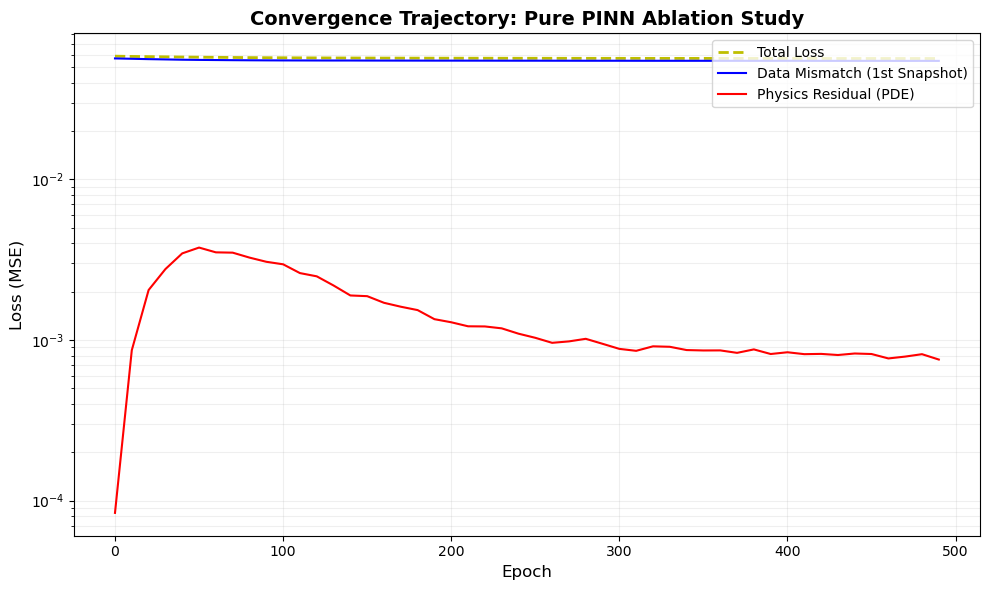

In [26]:
# ==========================================
# CELL 4: PURE PINN CONVERGENCE VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# [Rasht-Behesht 2022 Compliance]: Visualizing the evolution of the different 
# loss terms using a logarithmic scale to observe gradient convergence.

plt.figure(figsize=(10, 6), facecolor='white')

# Plotting on a logarithmic scale (Y-axis)
plt.semilogy(history['epoch'], history['total'], label='Total Loss', color='y', linestyle='--', linewidth=2)
plt.semilogy(history['epoch'], history['snap'], label='Data Mismatch (1st Snapshot)', color='b', linewidth=1.5)
plt.semilogy(history['epoch'], history['pde'], label='Physics Residual (PDE)', color='r', linewidth=1.5)

# Formatting the chart
plt.title('Convergence Trajectory: Pure PINN Ablation Study', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.2)

# Display the graphical analysis
plt.tight_layout()
plt.show()